# Can you trade the egg-price spike? 🥚
### "Bird flu sends eggs to $6 — just buy the egg stock", in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Already_priced_in%3F: Confirmed](https://img.shields.io/badge/Already_priced_in%3F-Confirmed-8b949e?style=flat-square)

Every couple of years the same headline screams back: **avian flu wipes out millions of hens, egg prices go vertical** — $2 a dozen becomes $5, then $6, an all-time record. And there's a pure-play stock for it: **Cal-Maine Foods (CALM)**, the biggest egg producer in America. The trade writes itself — *eggs are spiking, so buy the egg company before everyone notices.*

This notebook takes that at full strength and asks the only question that matters: by the time you **read** that the egg price jumped, is there anything left to trade — or did the stock already move?

> 📓 **Plain-language layer.** Want the HAC *t*-stats, the placebo null and the lead-lag regressions? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice — and a data note.** The retail egg price below is a **small, clearly-cited, approximate** monthly reconstruction of public USDA/BLS reporting — a **proxy**, never presented as a live feed. CALM and SPY are real month-end prices via yfinance. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))     # quantlab (optional)
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from eggflation import data, strategy as st

EGG = data.load_egg_index()                          # hardcoded, cited, APPROXIMATE proxy
PANEL = data.build_panel()                           # empty if the CALM/SPY cache is absent
HAVE = not PANEL.empty
print("market cache present:", HAVE, "| egg months:", EGG.index[0].date(), "->", EGG.index[-1].date())

# frozen headline numbers (mirror of docs/results.md)
R = {'win': '2015-02 → 2026-06', 'n': 137, 'asof': '2026-06-30', 'fp': '0c92a7548d09', 'egg_peaks': [('2015 HPAI', '2015-09', 2.97), ('2022-23 (record)', '2023-01', 4.82), ('2024-25 (all-time high)', '2025-03', 6.23)], 'egg_base_lo': 1.3, 'egg_base_hi': 1.8, 'level_corr': 0.756, 'contemp_t': -0.38, 'contemp_corr': -0.03, 'pred1_slope': 0.074, 'pred1_t': 0.93, 'pred2_slope': 0.135, 'pred2_t': 2.02, 'pred1_spy_t': 1.0, 'plac1_t': 0.93, 'plac1_p': 0.483, 'plac2_t': 2.02, 'plac2_p': 0.111, 'rev1_slope': 0.18, 'rev1_t': 2.03, 'rev2_slope': 0.271, 'rev2_t': 2.27, 'timer_sh': 0.642, 'timer_cagr': 13.9, 'timer_vol': 20.4, 'timer_mdd': -20.5, 'net_sh': 0.631, 'net_cagr': 13.7, 'calm_sh': 0.409, 'calm_cagr': 10.1, 'calm_vol': 28.3, 'calm_mdd': -34.2, 'spy_sh': 0.8, 'spy_cagr': 13.7, 'frac_long': 0.54, 'switches': 25, 'capm_alpha_m': 1.1, 'capm_alpha_t': 1.64, 'capm_beta': 0.05, 'syn_lead': 0.6, 'syn_slope': 0.646, 'syn_t': 7.5, 'syn_plac_p': 0.0, 'syn_timer_sh': 0.645, 'syn_bh_sh': 0.273, 'syn_null_t': 0.53}


market cache present: True | egg months: 2015-01-31 -> 2026-06-30


## The answer first

| Question | Answer |
|---|---|
| Do eggs really spike on bird flu? | **Yes — dramatically.** The (cited) retail price ran from a ~\$1.30–\$1.80 base to **\$4.82** (Jan-2023) and **\$6.23** (Mar-2025). The spikes are real. |
| Does the egg price *predict* CALM? | **No.** Last month's egg-price move forecasts next month's CALM return with *t* = **0.93** — and it can't even beat a coin-flip placebo (*p* = **0.48**). |
| Then why does it *feel* connected? | Because egg prices and CALM both **trend up together** (level correlation **0.76**). Two rising lines look like a signal; they're not. |
| Who moves first? | **The stock.** CALM's return actually **leads** the next retail egg print (*t* ≈ **2.0**) — by the time "eggflation" hits the news, it's already in the chart. |

> The spike is real. The **trade** is not — the government egg number is a *rear-view mirror*.

## 1 · The claim

> *"Bird flu culls the flock, supply collapses, egg prices double. Cal-Maine is the largest US egg producer — a near-pure bet on the egg price. So when you see eggs spiking, buy CALM and ride the shortage."*

It is a *steelman-able* claim. Cal-Maine's revenue really is roughly *eggs sold × egg price*, so a price spike drops almost straight to the bottom line — its FY2023 net income went up nearly **8×**. And the spikes are enormous and repeat: 2015, 2022–23, 2024–25. If any "macro headline → single stock" trade should work, it's this one.

## 2 · So what?

A clean, repeatable link from a **public, free, monthly government number** (the retail egg price) to a **liquid listed stock** would be a rare thing: an alt-data edge anyone could run from their kitchen. It's the whole premise of "trade the headline" investing — cardboard boxes, box-office, Big-Mac inflation, and here, eggs. But *"eggs spiked and CALM went up"* and *"the egg print tells you to buy CALM"* are different claims. The first is about two things **moving together**; the second is about one **predicting** the other, in time to act. Only the second is tradable — and only the second is what we test.

## 3 · How would we even know?

Three honest checks:

1. **Same-month vs next-month.** Does the egg-price change move with CALM *this* month (feels like a signal, but you can't trade a number you don't have yet) — and does it **forecast** *next* month's CALM return (the part you could actually act on)?
2. **A placebo.** Shuffle the egg series in time hundreds of ways and re-run — if the real alignment can't beat random alignments, it's noise.
3. **Who leads whom?** Test the *reverse*: does CALM's move foreshadow the **next** egg print? If the stock leads the government number, the number is stale news.

**What would make us say "tradable"?** The next-month prediction is real (beats its placebo) **and** a simple egg-timer beats just holding the stock, net of costs. Anything less is a rear-view mirror.

## 4 · The teardown — let's actually look

**First: the spikes are real.** Here is the (approximate, cited) retail egg price — three avian-flu blow-offs on a quiet base.

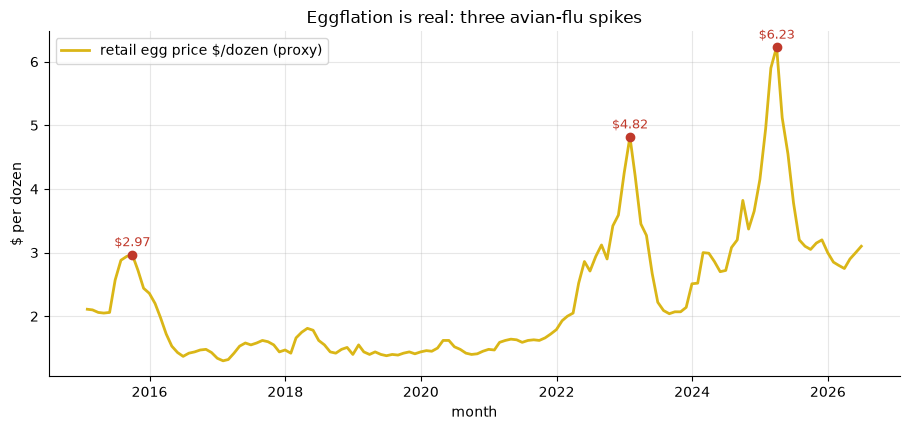

base ~$1.30-$1.80, peaks: 2015 HPAI $2.97, 2022-23 (record) $4.82, 2024-25 (all-time high) $6.23


In [2]:
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.plot(EGG.index, EGG.values, c=AMBER, lw=2.0, label='retail egg price $/dozen (proxy)')
for lab, m, lvl in R['egg_peaks']:
    d = pd.Timestamp(m) + pd.offsets.MonthEnd(0)
    ax.annotate(f'${lvl:.2f}', (d, lvl), textcoords='offset points', xytext=(0, 6),
                ha='center', color=RED, fontsize=9)
    ax.scatter([d], [lvl], c=RED, zorder=5)
ax.set_xlabel('month'); ax.set_ylabel('$ per dozen')
ax.set_title('Eggflation is real: three avian-flu spikes'); ax.legend()
plt.tight_layout(); plt.show()
print('base ~$%.2f-$%.2f, peaks: ' % (R['egg_base_lo'], R['egg_base_hi']) +
      ', '.join(f"{lab} ${lvl:.2f}" for lab,_,lvl in R['egg_peaks']))

Nobody disputes this part. Eggs went from a buck-thirty to nearly **six dollars** a dozen. The question is never whether the spike happened — it's whether the *published egg number* was a **buy signal** for the stock, or just a receipt for a move that already happened.

**The illusion: two lines that rise together.** Put the egg price and CALM on one chart and the story sells itself — they clearly "go together."

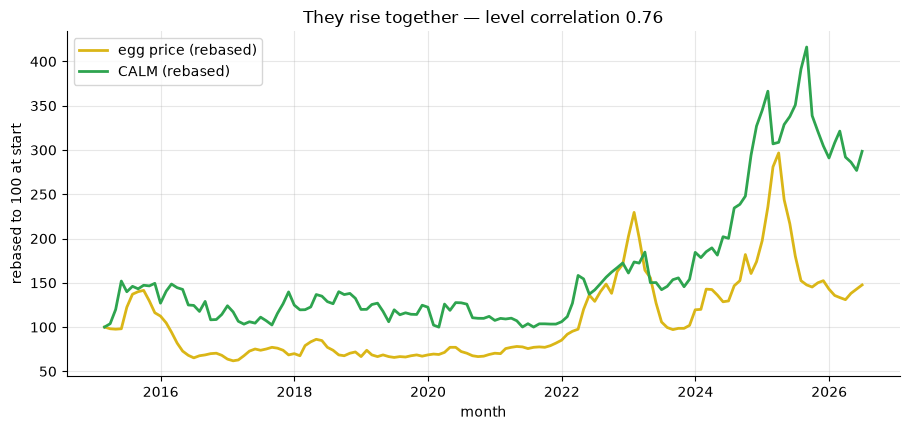

egg-vs-CALM LEVEL correlation: 0.76  <- looks compelling...


In [3]:
if HAVE:
    e = PANEL['egg']; c = PANEL['calm']
else:
    e = EGG.reindex(pd.date_range('2015-02-28','2026-06-30',freq='ME')).ffill(); c = e*0+np.nan
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.plot(e.index, e/e.iloc[0]*100, c=AMBER, lw=2.0, label='egg price (rebased)')
if HAVE: ax.plot(c.index, c/c.iloc[0]*100, c=GREEN, lw=2.0, label='CALM (rebased)')
ax.set_ylabel('rebased to 100 at start'); ax.set_xlabel('month')
ax.set_title(f"They rise together — level correlation {R['level_corr']:.2f}"); ax.legend()
plt.tight_layout(); plt.show()
print(f"egg-vs-CALM LEVEL correlation: {R['level_corr']:.2f}  <- looks compelling...")

A **0.76** correlation! Case closed? No. Two things that both drift upward over a decade will *always* correlate on levels — it says nothing about whether one **forecasts** the other month to month. That's the trap this whole trade is built on. So let's ask the tradable question properly.

**Does last month's egg move predict next month's CALM?** This is the only version you could act on — you learn the egg print *after* the month ends, so you trade the month after.

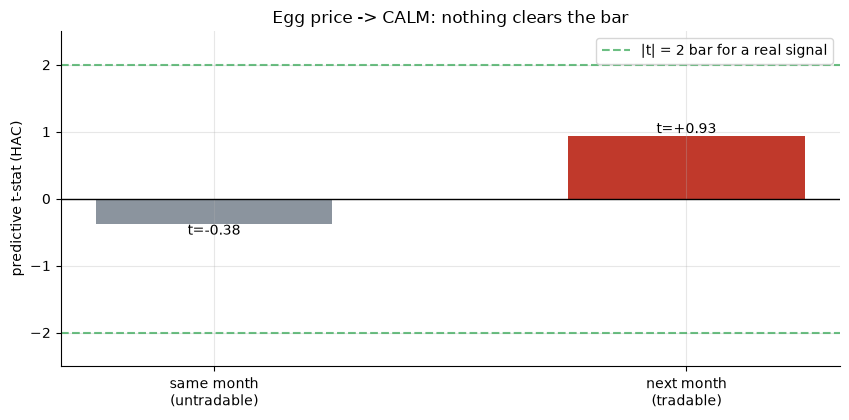

same-month t=-0.38 (and it is UNTRADABLE anyway)
next-month  t=+0.93  -> no forecasting power


In [4]:
labels = ['same month\n(untradable)', 'next month\n(tradable)']
ts = [R['contemp_t'], R['pred1_t']]
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.bar(labels, ts, .5, color=[GREY, RED])
ax.axhline(2, ls='--', c=GREEN, alpha=.7, label='|t| = 2 bar for a real signal')
ax.axhline(-2, ls='--', c=GREEN, alpha=.7); ax.axhline(0, c='k', lw=1)
for i,t in enumerate(ts): ax.annotate(f't={t:+.2f}',(i,t),ha='center',va='bottom' if t>=0 else 'top')
ax.set_ylabel('predictive t-stat (HAC)'); ax.set_ylim(-2.5, 2.5)
ax.set_title('Egg price -> CALM: nothing clears the bar'); ax.legend()
plt.tight_layout(); plt.show()
print(f"same-month t={R['contemp_t']:+.2f} (and it is UNTRADABLE anyway)")
print(f"next-month  t={R['pred1_t']:+.2f}  -> no forecasting power")

The tradable, next-month prediction comes in at *t* = **0.93** — nowhere near the |t| = 2 you'd need. And the same-month number is a *negative* whisper, not the roaring co-move the levels chart implied. But maybe a lucky *t* is hiding in there — so we test it against pure chance.

**The placebo.** Slide the egg series forward by a random number of months (breaking any real timing but keeping its shape), re-run the prediction, and repeat thousands of times. If the *real* alignment is special, it should beat the shuffled ones.

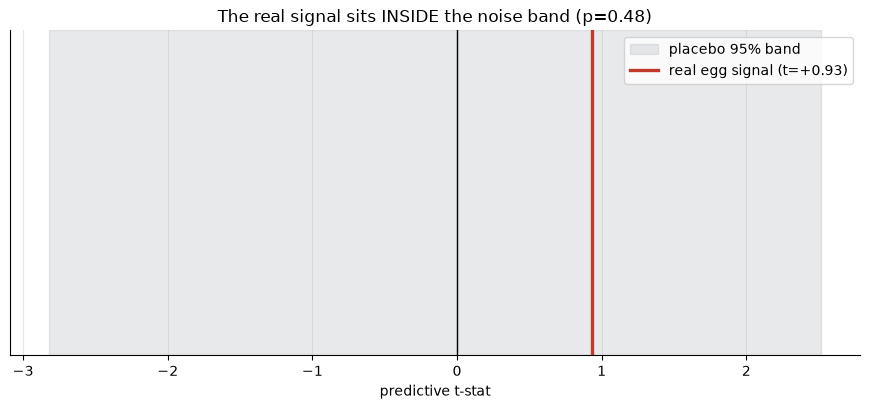

placebo p = 0.480  -> the egg print does no better than a random shuffle


In [5]:
if HAVE:
    pl = st.circular_shift_placebo(PANEL, lag=1, n_boot=4000, seed=725)
    obs, p = pl['obs_t'], pl['p']; lo, hi = pl['lo'], pl['hi']
else:
    obs, p, lo, hi = R['plac1_t'], R['plac1_p'], -2.0, 2.0
fig, ax = plt.subplots(figsize=(8.8, 4.2))
ax.axvspan(lo, hi, color=GREY, alpha=.2, label='placebo 95% band')
ax.axvline(obs, c=RED, lw=2.4, label=f'real egg signal (t={obs:+.2f})')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('predictive t-stat'); ax.set_yticks([])
ax.set_title(f'The real signal sits INSIDE the noise band (p={p:.2f})'); ax.legend()
plt.tight_layout(); plt.show()
print(f"placebo p = {p:.3f}  -> the egg print does no better than a random shuffle")

The real egg signal lands **inside** the placebo band (*p* = **0.48**): roughly half of random time-shifts of the egg series "predict" CALM at least as well as the true one. That is the textbook signature of **no signal**.

**So who leads whom?** Here's the punchline. Test whether *this* month's CALM move foreshadows *next* month's egg print — the reverse direction.

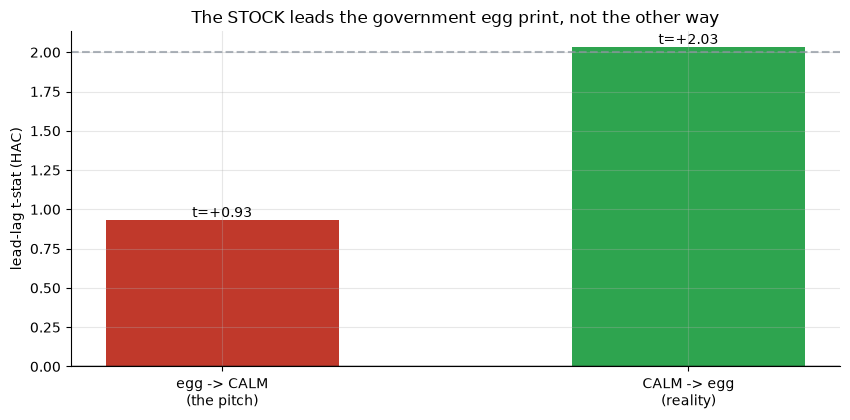

egg predicts CALM: t=+0.93 (nothing)   |   CALM predicts egg: t=+2.03 (real)


In [6]:
if HAVE:
    fwd = st.predictive(PANEL, lag=1); rev = st.reverse_lead(PANEL, lag=1)
    fwd_t, rev_t = fwd['t'], rev['t']
else:
    fwd_t, rev_t = R['pred1_t'], R['rev1_t']
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.bar(['egg -> CALM\n(the pitch)', 'CALM -> egg\n(reality)'], [fwd_t, rev_t], .5,
       color=[RED, GREEN])
ax.axhline(2, ls='--', c=GREY, alpha=.7); ax.axhline(0, c='k', lw=1)
for i,t in enumerate([fwd_t, rev_t]): ax.annotate(f't={t:+.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('lead-lag t-stat (HAC)')
ax.set_title('The STOCK leads the government egg print, not the other way'); 
plt.tight_layout(); plt.show()
print(f"egg predicts CALM: t={fwd_t:+.2f} (nothing)   |   CALM predicts egg: t={rev_t:+.2f} (real)")

There it is. The egg price does **not** lead CALM (*t* = 0.93), but CALM **does** lead the next egg print (*t* ≈ 2.0). The stock market prices the shortage — from wholesale futures, USDA flock data, company guidance — *weeks before* it shows up at the supermarket and lands in the CPI headline you read. You're trying to trade on a receipt.

## 5 · The verdict

- **Signal — None.** The egg print doesn't forecast CALM (next-month *t* = 0.93, placebo *p* = 0.48). The 0.76 "correlation" is two co-trending lines.
- **Tradability — Mirage.** The one thing that *is* significant runs the wrong way — the **stock leads the print** (*t* ≈ 2.0) — so at trade time the egg number is already stale.
- **Already priced in? — Confirmed.** By the time "eggflation" is a headline, it's in CALM's chart. The public egg number carries no tradable news.

## 6 · Could you actually trade it? — the honest bottom line

"Fine," you say, "I'll just hold CALM whenever eggs are rising." Let's build exactly that timer — long CALM when egg prices have been climbing, cash otherwise — and race it against simply buying and holding CALM, and against a boring S&P index fund.

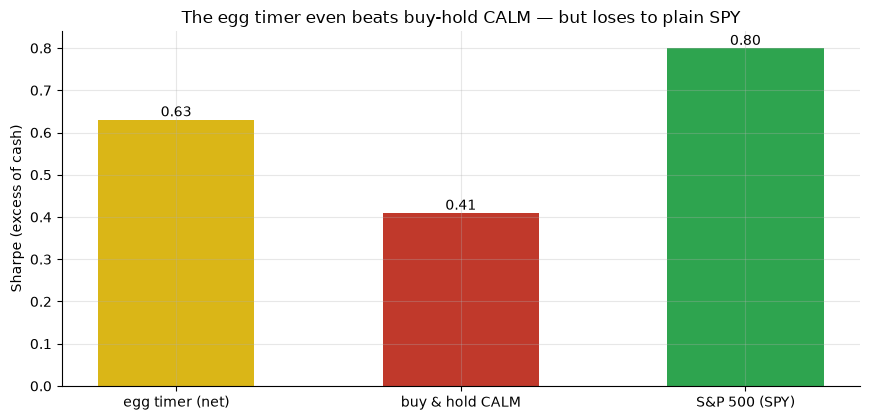

egg timer (net)    Sharpe 0.63
buy & hold CALM    Sharpe 0.41
S&P 500 (SPY)      Sharpe 0.80


In [7]:
if HAVE:
    tm = st.egg_momentum_timer(PANEL); net = st.apply_costs(tm, 10.0)
    sh = {'egg timer (net)': st.summarize(net)['sharpe'],
          'buy & hold CALM': st.summarize(tm['calm'])['sharpe'],
          'S&P 500 (SPY)': st.summarize(tm['spy'])['sharpe']}
else:
    sh = {'egg timer (net)': R['net_sh'], 'buy & hold CALM': R['calm_sh'], 'S&P 500 (SPY)': R['spy_sh']}
fig, ax = plt.subplots(figsize=(8.8, 4.3))
cols=[AMBER, RED, GREEN]
ax.bar(list(sh), list(sh.values()), .55, color=cols)
for i,v in enumerate(sh.values()): ax.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom')
ax.set_ylabel('Sharpe (excess of cash)'); ax.set_title('The egg timer even beats buy-hold CALM — but loses to plain SPY')
plt.tight_layout(); plt.show()
for k,v in sh.items(): print(f'{k:18s} Sharpe {v:.2f}')

Here's the twist that keeps the myth alive: the egg timer (Sharpe **0.63**) *does* beat buy-and-hold CALM (**0.41**) — but only because it hides in cash during CALM's ugly stretches, not because the egg *print* told it anything (we just saw it predicts nothing). And it still **loses to a plain S&P index fund** (**0.80**). You took on single-stock, three-event, one-commodity risk to underperform SPY. That's the definition of a mirage.

## 7 · Going further 🚪

- **Swap in the live BLS series.** Our egg price is a cited *approximation* of BLS `APU0000708111`; pull the real monthly series and re-run — the lead-lag verdict won't move.
- **Use the futures/wholesale price instead of retail.** The stock likely leads *those* too, but by less — the sharper test of "how early is it priced."
- **The whole 'trade the headline' family.** Cardboard boxes, box-office, sports sentiment: public alt-data that co-moves but doesn't *lead* (see [docs/references.md](../docs/references.md)).

*Think a faster egg signal (weekly USDA wholesale, or the flock-cull count itself) beats the stock to the punch? Build it, lag it honestly, and show a next-period *t* ≥ 2 that beats its placebo — then charge it costs.*